<a href="https://colab.research.google.com/github/Yasmeen20110210/Final_Project/blob/main/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

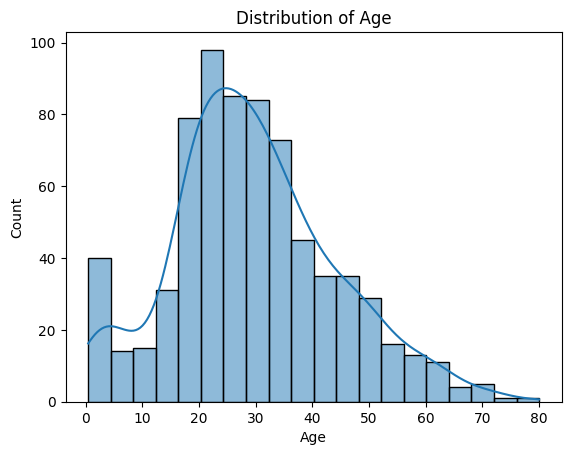

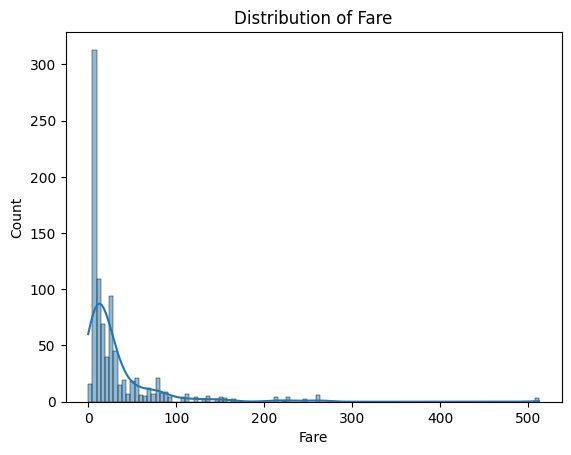

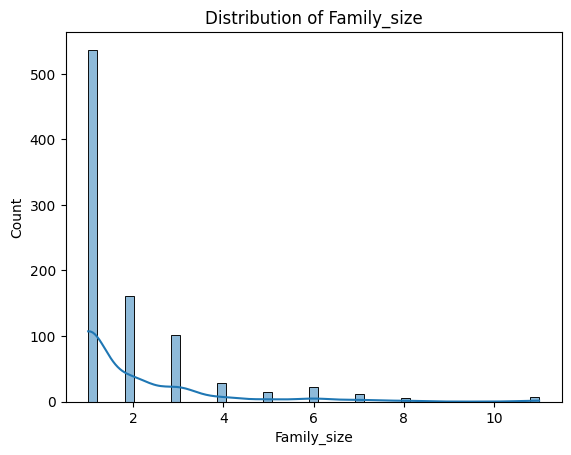

Age: the distribution is slightly right-skewed with most passengers between 20–40
Fare: highly right-skewed because a few passengers paid very high fares


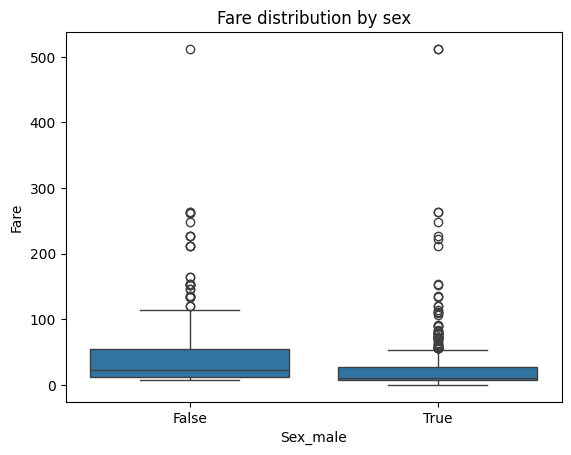

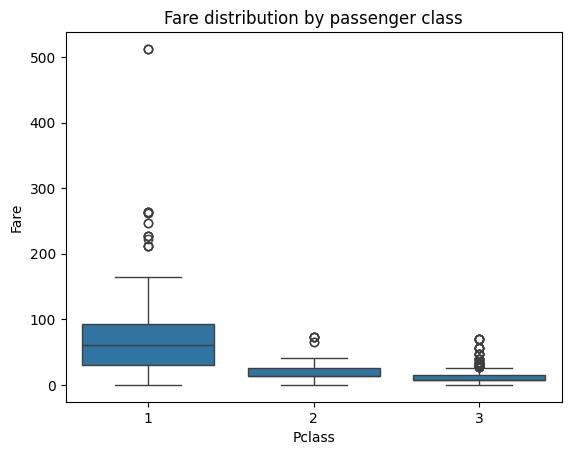

Passengers in first class paid significantly higher fares than those in lower classes


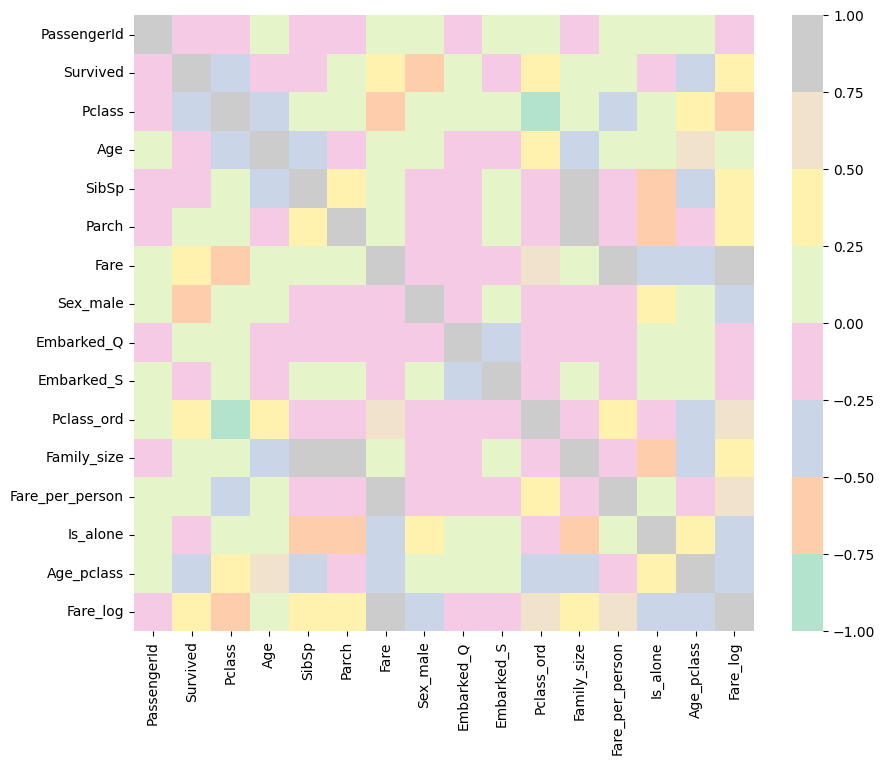

Top 10 correlated features: Survived           1.000000
Pclass_ord         0.338481
Fare_log           0.329862
Fare               0.257307
Fare_per_person    0.221600
Parch              0.081629
Family_size        0.016639
Embarked_Q         0.003650
PassengerId       -0.005007
SibSp             -0.035322
Name: Survived, dtype: float64


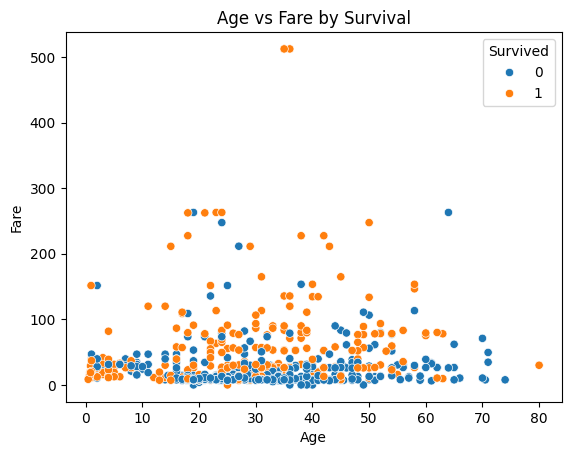

Passengers paying higher fares were more likely to survive, especially those in higher classes
Survival buy sex : Sex_male
False    0.742038
True     0.188908
Name: Survived, dtype: float64


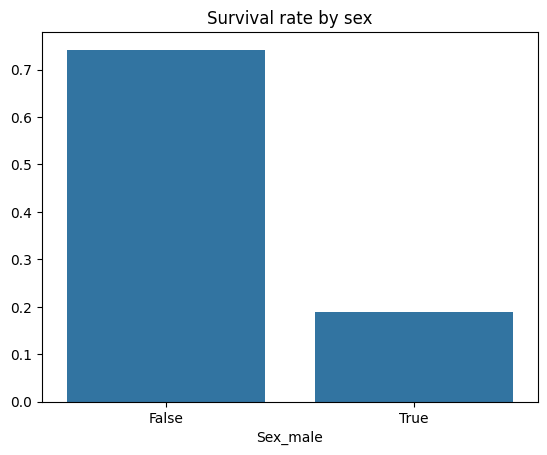

Female passengers had a significantly higher survival rate compared to male passengers


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Import everything I need
titanic = pd.read_csv("Titanic_features.csv")
# Load the dataset that I saved from the last file (02_features)
num_cols = ["Age", "Fare", "Family_size"]
# Select 3 numerical columns
for col in num_cols:
    sns.histplot(titanic[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
# Hist plot + kde for the 3 columns
print("Age: the distribution is slightly right-skewed with most passengers between 20–40")
print("Fare: highly right-skewed because a few passengers paid very high fares")

sns.boxplot(x="Sex_male", y="Fare", data=titanic)
plt.title("Fare distribution by sex")
plt.show()
sns.boxplot(x="Pclass", y="Fare", data=titanic)
plt.title("Fare distribution by passenger class")
plt.show()
print("Passengers in first class paid significantly higher fares than those in lower classes")
# Grouped boxplot with two categories (pclass and sex )

corr = titanic.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="Pastel2")
plt.show()
# Do correlation to search for the features that relate to Surviving the most

corr_target = corr["Survived"].sort_values(ascending=False)

print("Top 10 correlated features:",corr_target.head(10))
# Top 10 correlated features

sns.scatterplot(
    x="Age",
    y="Fare",
    hue="Survived",
    data=titanic
)

plt.title("Age vs Fare by Survival")
plt.show()
print("Passengers paying higher fares were more likely to survive, especially those in higher classes")
# Scatter plot on age and fare, and the color represents whether the passenger survived or not
survival_by_sex = titanic.groupby("Sex_male")["Survived"].mean()

print("Survival buy sex :",survival_by_sex)
# The mean of survival
sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values)
plt.title("Survival rate by sex")
plt.show()
print("Female passengers had a significantly higher survival rate compared to male passengers")